# Explainable AML modeling — simple MVP

This notebook compares **logistic regression, XGBoost, and Explainable Boosting Machine (EBM)** on IBM's synthetic HI-Small transaction data. It reads a reproducible 10% sample, makes a chronological train/validation/test split, fits the three models, and shows metrics and explanations. Run the cells from top to bottom.

This is a class demonstration on **sampled synthetic data**. A score ranks transactions for review; it is not a real laundering probability or an investigator conclusion. The [project guide](docs/PROJECT_GUIDE.md) explains the choices and limitations. The raw CSV stays local; tables and charts are saved in this notebook, not in a `results/` folder.

## 1. Imports and settings

Put `HI-Small_Trans.csv` at `data/raw/HI-Small_Trans.csv` as described in the [README](README.md). The random seed makes the same 10% rows appear on repeated runs with the same CSV and row order.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, DMatrix
from interpret.glassbox import ExplainableBoostingClassifier

DATA_PATH = Path("data/raw/HI-Small_Trans.csv")
SEED = 42
SAMPLE_FRACTION = 0.10
ALERT_CAPACITY = 100
print("Dataset:", DATA_PATH)
print("Sample fraction:", SAMPLE_FRACTION)

Dataset: data/raw/HI-Small_Trans.csv
Sample fraction: 0.1


## 2. Load a manageable sample

The CSV has about five million rows. Reading it in chunks lets us keep about 10% of transactions before September 11 without holding the entire file in pandas. The final days have an unusual label rate, so this simple experiment leaves them out. Bank and account IDs are read as text to preserve leading zeros.

In [2]:
rng = np.random.default_rng(SEED)
parts = []
for chunk in pd.read_csv(
    DATA_PATH,
    chunksize=100_000,
    usecols=["Timestamp", "From Bank", "Account", "To Bank", "Amount Paid",
             "Payment Currency", "Payment Format", "Is Laundering"],
    dtype={"From Bank": str, "Account": str, "To Bank": str},
):
    timestamps = pd.to_datetime(chunk["Timestamp"])
    keep = (timestamps < "2022-09-11") & (rng.random(len(chunk)) < SAMPLE_FRACTION)
    parts.append(chunk.loc[keep])

transactions = pd.concat(parts, ignore_index=True).rename(columns={
    "Timestamp": "timestamp",
    "From Bank": "from_bank",
    "Account": "from_account",
    "To Bank": "to_bank",
    "Amount Paid": "amount_paid",
    "Payment Currency": "payment_currency",
    "Payment Format": "payment_format",
    "Is Laundering": "label",
})
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])
transactions = transactions.sort_values("timestamp", kind="stable").reset_index(drop=True)
print(f"Sampled rows: {len(transactions):,}")
print(f"Positive labels: {transactions['label'].sum():,} ({transactions['label'].mean():.3%})")
display(transactions[["timestamp", "amount_paid", "payment_currency", "payment_format", "label"]].head())

Sampled rows: 507,333
Positive labels: 475 (0.094%)


,timestamp,amount_paid,payment_currency,payment_format,label
0,2022-09-01,897.37,US Dollar,Reinvestment,0
1,2022-09-01,400.56,US Dollar,Reinvestment,0
2,2022-09-01,18.27,US Dollar,Reinvestment,0
3,2022-09-01,16189.28,US Dollar,Reinvestment,0
4,2022-09-01,55538.73,US Dollar,Reinvestment,0


## 3. Create a few understandable features

The current transaction contributes amount, hour, same-bank status, format, and currency. `prior_sender_count` counts **earlier sampled transactions** from the same sender. We count by timestamp first, so transactions at the same time do not see one another. Because only 10% of rows were loaded, this count is **incomplete account history**; it is a simple classroom feature.

In [3]:
transactions["sender"] = transactions["from_bank"] + ":" + transactions["from_account"]
counts = transactions.groupby(["sender", "timestamp"]).size().reset_index(name="at_this_time")
counts["prior_sender_count"] = (
    counts.groupby("sender")["at_this_time"].cumsum() - counts["at_this_time"]
)
transactions = transactions.merge(
    counts[["sender", "timestamp", "prior_sender_count"]],
    on=["sender", "timestamp"],
    how="left",
)
transactions["log_amount"] = np.log1p(transactions["amount_paid"])
transactions["hour"] = transactions["timestamp"].dt.hour
transactions["same_bank"] = (transactions["from_bank"] == transactions["to_bank"]).astype(int)

print("Feature example:")
display(transactions[["log_amount", "hour", "same_bank", "prior_sender_count"]].head())

Feature example:


,log_amount,hour,same_bank,prior_sender_count
0,6.800582,0,1,0
1,5.995357,0,1,0
2,2.958549,0,1,0
3,9.692166,0,1,0
4,10.924854,0,1,0


## 4. Split by time and encode categories

Training uses September 1–6, validation September 7–8, and September 9–10 is held out for reporting. We choose the model using validation average precision. Payment format and currency are turned into numeric indicator columns using training categories only.

In [4]:
train = transactions[transactions["timestamp"] < "2022-09-07"].copy()
validation = transactions[
    (transactions["timestamp"] >= "2022-09-07") &
    (transactions["timestamp"] < "2022-09-09")
].copy()
test = transactions[transactions["timestamp"] >= "2022-09-09"].copy()

split_summary = pd.DataFrame({
    "period": ["train", "validation", "test"],
    "rows": [len(train), len(validation), len(test)],
    "positive_labels": [train["label"].sum(), validation["label"].sum(), test["label"].sum()],
})
split_summary["label_rate"] = split_summary["positive_labels"] / split_summary["rows"]
display(split_summary)

feature_columns = ["log_amount", "hour", "same_bank", "prior_sender_count",
                   "payment_format", "payment_currency"]
categories = ["payment_format", "payment_currency"]
X_train = pd.get_dummies(train[feature_columns], columns=categories, dtype=float)
X_validation = pd.get_dummies(validation[feature_columns], columns=categories, dtype=float)
X_test = pd.get_dummies(test[feature_columns], columns=categories, dtype=float)
X_validation = X_validation.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_train = train["label"]
y_validation = validation["label"]
y_test = test["label"]
print("Model features:", len(X_train.columns))
display(X_train.head())

,period,rows,positive_labels,label_rate
0,train,324521,260,0.000801
1,validation,96746,112,0.001158
2,test,86066,103,0.001197


Model features: 26


,log_amount,hour,same_bank,prior_sender_count,payment_format_ACH,payment_format_Bitcoin,payment_format_Cash,payment_format_Cheque,payment_format_Credit Card,payment_format_Reinvestment,...,payment_currency_Mexican Peso,payment_currency_Ruble,payment_currency_Rupee,payment_currency_Saudi Riyal,payment_currency_Shekel,payment_currency_Swiss Franc,payment_currency_UK Pound,payment_currency_US Dollar,payment_currency_Yen,payment_currency_Yuan
0,6.800582,0,1,0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,5.995357,0,1,0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.958549,0,1,0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,9.692166,0,1,0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,10.924854,0,1,0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 5. Fit the three models

Logistic regression is the simple linear baseline. XGBoost learns nonlinear tree patterns. EBM learns interpretable additive effects. All three fit only the training rows. The labels are rare, so each model gives positive training rows more weight.

In [5]:
positive_weight = (len(y_train) - y_train.sum()) / y_train.sum()
models = {
    "Logistic regression": make_pipeline(
        StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=500)
    ),
    "XGBoost": XGBClassifier(
        n_estimators=120, max_depth=3, learning_rate=0.08,
        scale_pos_weight=positive_weight, tree_method="hist", n_jobs=4,
        eval_metric="logloss", random_state=SEED,
    ),
    "EBM": ExplainableBoostingClassifier(
        interactions=0, outer_bags=1, max_rounds=200, n_jobs=4, random_state=SEED
    ),
}
models["Logistic regression"].fit(X_train, y_train)
models["XGBoost"].fit(X_train, y_train)
weights = np.where(y_train == 1, positive_weight, 1.0)
models["EBM"].fit(X_train, y_train, sample_weight=weights)
print("Fitted:", ", ".join(models))

Fitted: Logistic regression, XGBoost, EBM


## 6. Compare ranking quality and top alerts

**Average precision (AP)** is useful when positive labels are rare. **ROC-AUC** is another ranking measure. Precision@100 asks how many of the 100 highest scores are positive; Recall@100 asks what fraction of all positives those 100 contain. We choose the model with the best **validation AP** and then read its test result.

Selected using validation AP: XGBoost


,model,period,average_precision,roc_auc,positives_in_top_100,precision_at_100,recall_at_100
0,Logistic regression,validation,0.0057,0.9068,0,0.00,0.0000
1,Logistic regression,test,0.0055,0.8972,0,0.00,0.0000
2,XGBoost,validation,0.0432,0.9656,11,0.11,0.0982
3,XGBoost,test,0.0334,0.9625,5,0.05,0.0485
4,EBM,validation,0.0179,0.9496,0,0.00,0.0000
5,EBM,test,0.0225,0.9546,4,0.04,0.0388


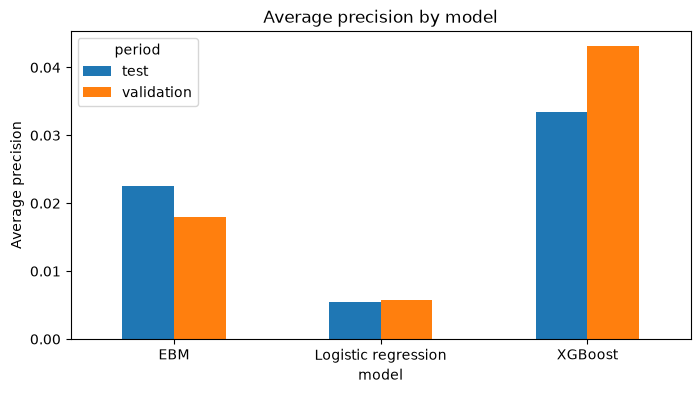

Highest-ranked test transactions:


,timestamp,amount_paid,payment_currency,payment_format,label,model_score
450005,2022-09-09 10:17:00,17747.80,Saudi Riyal,ACH,0,0.979950
447980,2022-09-09 09:31:00,15455.41,Saudi Riyal,ACH,0,0.979950
494034,2022-09-10 07:37:00,14553.25,Saudi Riyal,ACH,0,0.979950
494992,2022-09-10 08:48:00,13687.90,Saudi Riyal,ACH,0,0.979950
494182,2022-09-10 07:47:00,14685.17,Saudi Riyal,ACH,0,0.979950
500771,2022-09-10 15:58:00,14068.64,Saudi Riyal,ACH,0,0.979950
464339,2022-09-09 15:42:00,12201.13,Saudi Riyal,ACH,0,0.979950
494194,2022-09-10 07:48:00,9468.85,Saudi Riyal,ACH,0,0.979950
470870,2022-09-09 18:05:00,13242.25,Saudi Riyal,ACH,0,0.979216
494328,2022-09-10 07:59:00,18473.51,Saudi Riyal,ACH,0,0.978636


In [6]:
rows = []
scores = {}
for name, model in models.items():
    for period, X, y in [
        ("validation", X_validation, y_validation),
        ("test", X_test, y_test),
    ]:
        score = model.predict_proba(X)[:, 1]
        scores[(name, period)] = score
        top_100 = np.argsort(-score)[:ALERT_CAPACITY]
        positives_found = int(y.iloc[top_100].sum())
        rows.append({
            "model": name,
            "period": period,
            "average_precision": average_precision_score(y, score),
            "roc_auc": roc_auc_score(y, score),
            "positives_in_top_100": positives_found,
            "precision_at_100": positives_found / ALERT_CAPACITY,
            "recall_at_100": positives_found / y.sum(),
        })
results = pd.DataFrame(rows)
selected_model = (
    results[results["period"] == "validation"]
    .sort_values("average_precision", ascending=False)
    .iloc[0]["model"]
)
print("Selected using validation AP:", selected_model)
display(results.round(4))
results.pivot(index="model", columns="period", values="average_precision").plot.bar(
    figsize=(8, 4), title="Average precision by model"
)
plt.ylabel("Average precision")
plt.xticks(rotation=0)
plt.show()

top = np.argsort(-scores[(selected_model, "test")])[:10]
top_transactions = test.iloc[top][[
    "timestamp", "amount_paid", "payment_currency", "payment_format", "label"
]].copy()
top_transactions["model_score"] = scores[(selected_model, "test")][top]
print("Highest-ranked test transactions:")
display(top_transactions)

## 7. Explain what the models learned

The logistic coefficients and EBM terms are **global** summaries. XGBoost's native Tree SHAP values explain one high-scored test row; these values add to the model's raw log-odds score. Explanations describe model behavior, not proof of laundering.

In [7]:
logistic = models["Logistic regression"].named_steps["logisticregression"]
coefficients = pd.Series(logistic.coef_[0], index=X_train.columns)
print("Logistic regression: largest coefficients")
display(coefficients.reindex(coefficients.abs().sort_values(ascending=False).index).head(10))

xgboost = models["XGBoost"]
most_flagged = np.argmax(scores[("XGBoost", "test")])
contributions = xgboost.get_booster().predict(
    DMatrix(X_test.iloc[[most_flagged]]), pred_contribs=True
)[0][:-1]
shap_values = pd.Series(contributions, index=X_train.columns)
print("XGBoost Tree SHAP: largest contributions for one high-scored row")
display(shap_values.reindex(shap_values.abs().sort_values(ascending=False).index).head(10))

ebm = models["EBM"]
ebm_terms = pd.Series(ebm.term_importances(), index=ebm.term_names_)
print("EBM: most important global terms")
display(ebm_terms.sort_values(ascending=False).head(10))

Logistic regression: largest coefficients


payment_format_Wire           -1.887921
payment_format_Reinvestment   -1.754779
payment_format_ACH             1.592097
same_bank                     -0.814955
prior_sender_count             0.717732
log_amount                     0.531111
payment_format_Cheque          0.450877
payment_format_Credit Card     0.328309
payment_currency_Bitcoin       0.312786
payment_format_Bitcoin         0.297963
dtype: float64

XGBoost Tree SHAP: largest contributions for one high-scored row


payment_format_ACH              2.803982
log_amount                      0.593046
payment_currency_Saudi Riyal    0.558923
prior_sender_count             -0.278406
hour                            0.136020
same_bank                       0.064596
payment_currency_Bitcoin       -0.021839
payment_currency_Shekel         0.018904
payment_currency_Swiss Franc    0.016793
payment_format_Bitcoin         -0.013553
dtype: float32

EBM: most important global terms


payment_format_ACH             2.282138
prior_sender_count             1.008009
log_amount                     0.541976
payment_format_Cheque          0.301176
same_bank                      0.283333
payment_format_Credit Card     0.263804
payment_format_Reinvestment    0.204560
hour                           0.116683
payment_format_Cash            0.089922
payment_format_Wire            0.051300
dtype: float64

## 8. What this MVP can claim

This notebook demonstrates a **time-based comparison of three models on sampled synthetic transactions**. It does not evaluate every original row. The `prior_sender_count` feature sees only sampled earlier transactions, so it understates true account history. Same-timestamp transactions are treated together, but richer 24-hour and seven-day behavior is left for later work.

The September 11–18 data has a sharp volume and label-rate shift and is excluded from this simple experiment. Class weighting helps with rare labels, but model scores are **not calibrated probabilities**. The figures and top-ranked examples are educational results, not operational AML validation. Databricks and dbt remain a possible future data-engineering layer, as described in the [project guide](docs/PROJECT_GUIDE.md).